# **Upfall Dataset Exploration**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Upfall Description

* 17 young subjects (mostly around 20 years old).
* 11 types of activities: 5 types of falls (IDs 1-5) and 6 types of ADLs (IDs 6-11).
* Data from 5 wearable IMUs (Neck, Belt, Wrist, Ankle, Pocket), 1 EEG headset, and 6 Infrared sensors (ambient).
* Each subject performed 3 trials per activity.
* Each IMU contains a 3-axis accelerometer, 3-axis gyroscope, and a luminosity sensor.
* Provides both raw files per trial and a CompleteDataset.csv for global analysis.
* https://sites.google.com/up.edu.mx/har-up/

In [2]:
subjects_data = [
    [1, 18, 1.70, 99], [2, 20, 1.70, 58], [3, 19, 1.57, 54], [4, 20, 1.62, 71],
    [5, 21, 1.71, 69], [6, 22, 1.62, 68], [7, 24, 1.74, 70], [8, 23, 1.75, 88],
    [9, 23, 1.68, 70], [10, 19, 1.69, 63], [11, 20, 1.65, 73], [12, 19, 1.60, 53],
    [13, 20, 1.64, 55], [14, 19, 1.70, 73], [15, 21, 1.57, 56], [16, 20, 1.70, 62],
    [17, 20, 1.66, 54]
]
df_subjects_info = pd.DataFrame(subjects_data, columns=['Subject', 'Age', 'Height', 'Weight'])


In [3]:
upfall_path = "UpFall/CompleteDataset.csv"
df = pd.read_csv(upfall_path, low_memory=False, skiprows=1)

df = df.rename(columns={
    df.columns[-4]: 'Subject',
    df.columns[-3]: 'Activity',
    df.columns[-2]: 'Trial',
    df.columns[-1]: 'Tag'
})

for col in ['Subject', 'Activity', 'Trial']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=['Subject', 'Activity'])

In [4]:
df['Category'] = df['Activity'].apply(lambda x: 'Fall' if x <= 5 else 'ADL')

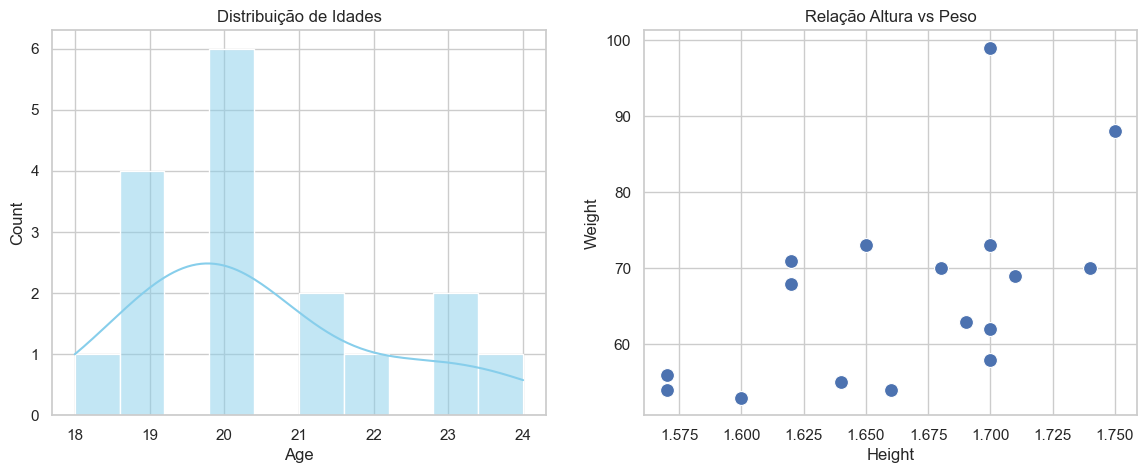

In [5]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_subjects_info['Age'], bins=10, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Idades')
sns.scatterplot(data=df_subjects_info, x='Height', y='Weight', s=100, ax=axes[1])
axes[1].set_title('Relação Altura vs Peso')
plt.show()

C:\Users\leono\AppData\Local\Temp\ipykernel_1616\741105154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=trials_unique, x='Category', palette='viridis')


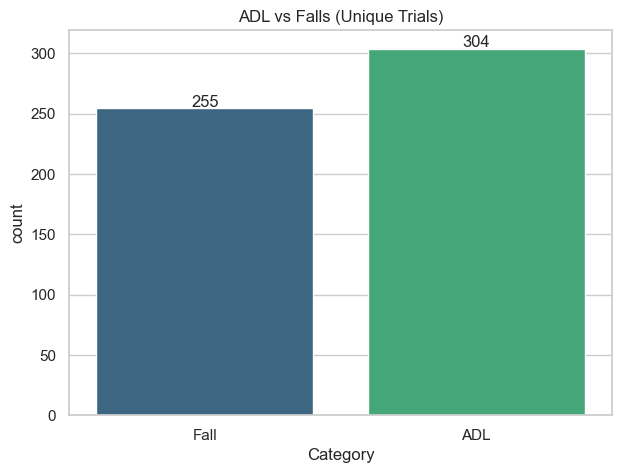

In [7]:
trials_unique = df.groupby(['Subject', 'Activity', 'Trial', 'Category']).size().reset_index()

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=trials_unique, x='Category', palette='viridis')
plt.title("ADL vs Falls (Unique Trials)")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.35, p.get_height()+1))
plt.show()

C:\Users\leono\AppData\Local\Temp\ipykernel_1616\183452771.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Category', palette='viridis', order=['ADL', 'Fall'])


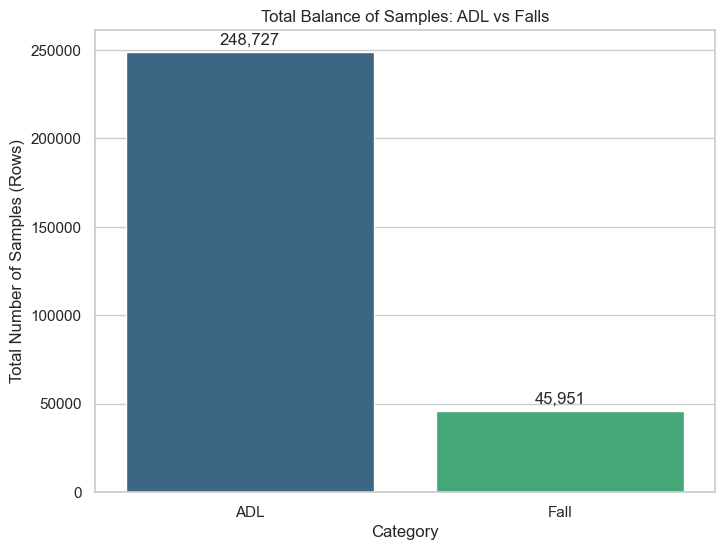

Total Number of Samples: 294,678
ADL: 248,727 (84.41%)
Fall: 45,951 (15.59%)


In [14]:

plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x='Category', palette='viridis', order=['ADL', 'Fall'])

plt.title("Total Balance of Samples: ADL vs Falls")
plt.ylabel("Total Number of Samples (Rows)")
plt.xlabel("Category")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', # O :, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.show()
total = len(df)
counts = df['Category'].value_counts()
print(f"Total Number of Samples: {total:,}")
print(f"ADL: {counts['ADL']:,} ({counts['ADL']/total*100:.2f}%)")
print(f"Fall: {counts['Fall']:,} ({counts['Fall']/total*100:.2f}%)")

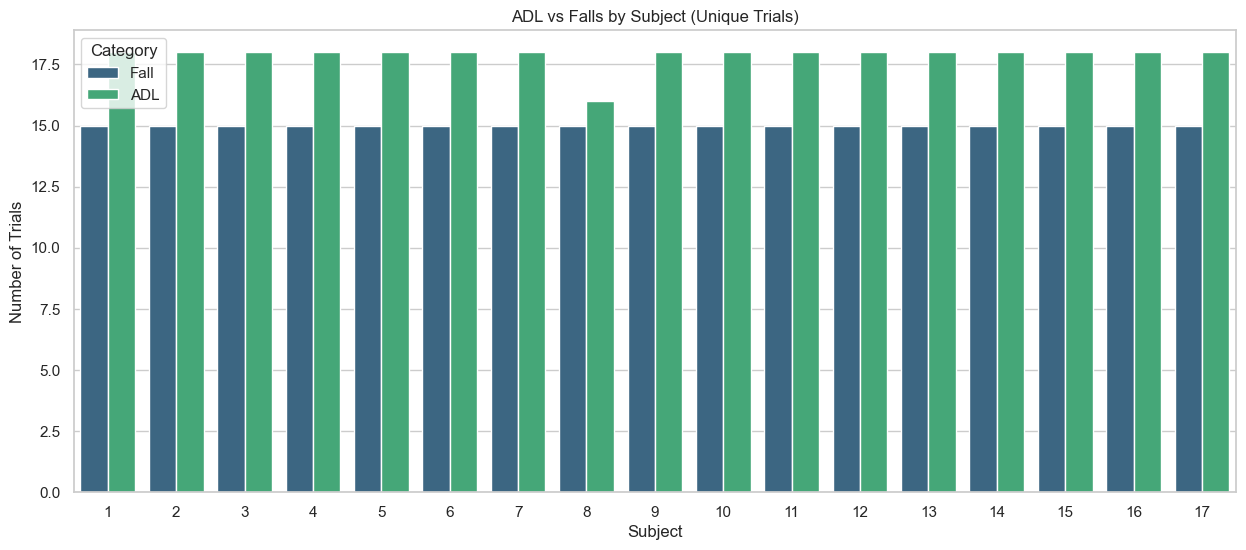

In [16]:
plt.figure(figsize=(15, 6))
sns.countplot(data=trials_unique, x='Subject', hue='Category', palette='viridis')
plt.title("ADL vs Falls by Subject (Unique Trials)")
plt.ylabel("Number of Trials")
plt.show()

C:\Users\leono\AppData\Local\Temp\ipykernel_1616\79847931.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_falls_only, x='Description', palette='Reds_r')


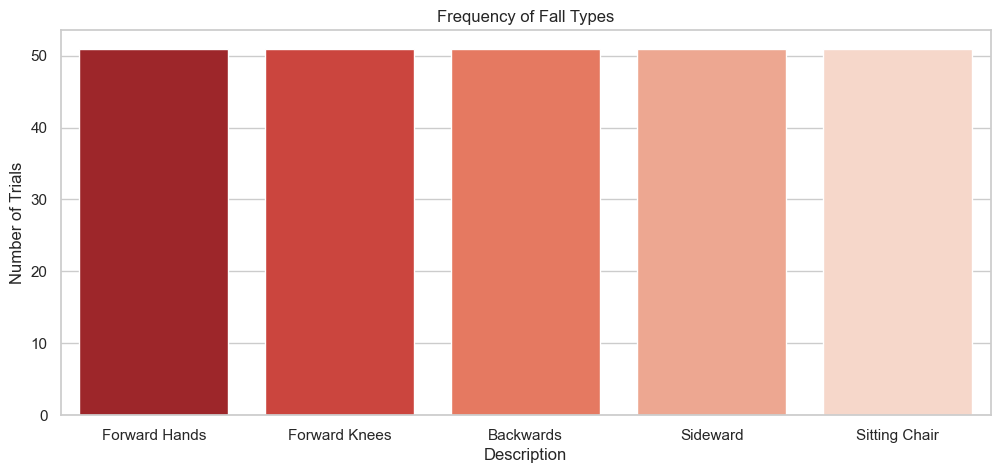

In [10]:
fall_descriptions = {
    1: "Forward Hands", 2: "Forward Knees", 3: "Backwards", 
    4: "Sideward", 5: "Sitting Chair"
}
df_falls_only = trials_unique[trials_unique['Category'] == 'Fall'].copy()
df_falls_only['Description'] = df_falls_only['Activity'].map(fall_descriptions)

plt.figure(figsize=(12, 5))
sns.countplot(data=df_falls_only, x='Description', palette='Reds_r')
plt.title("Frequency of Fall Types")
plt.ylabel("Number of Trials")
plt.show()

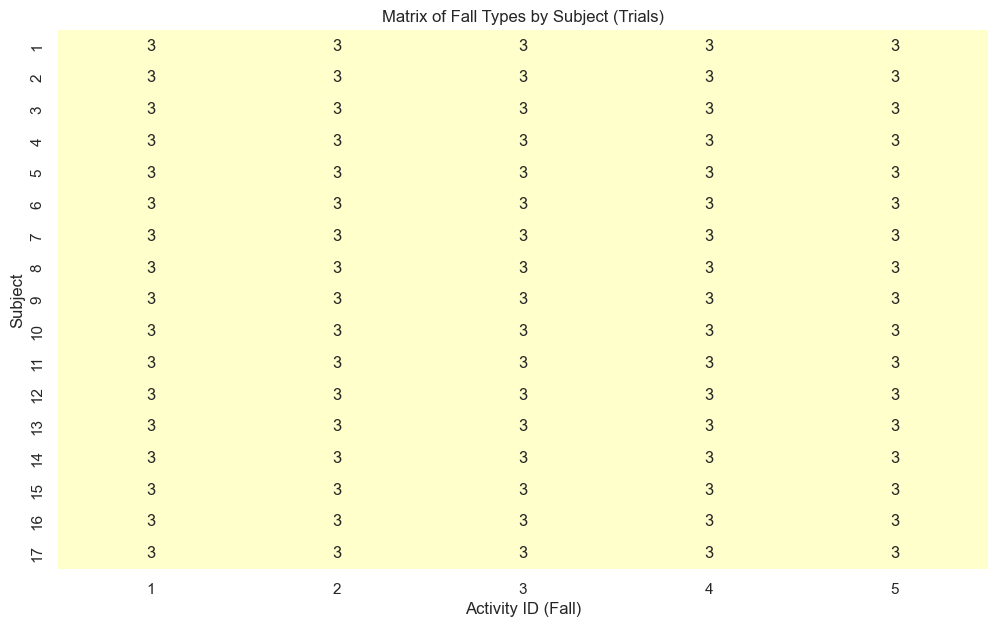

In [12]:
fall_pivot = df_falls_only.groupby(['Subject', 'Activity']).size().unstack(fill_value=0)
plt.figure(figsize=(12, 7))
sns.heatmap(fall_pivot, annot=True, cmap="YlOrRd", cbar=False)
plt.title("Matrix of Fall Types by Subject (Trials)")
plt.xlabel("Activity ID (Fall)")
plt.show()

C:\Users\leono\AppData\Local\Temp\ipykernel_1616\1268928954.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=subject_samples, x='Subject', y='percentage', palette='Blues_d')


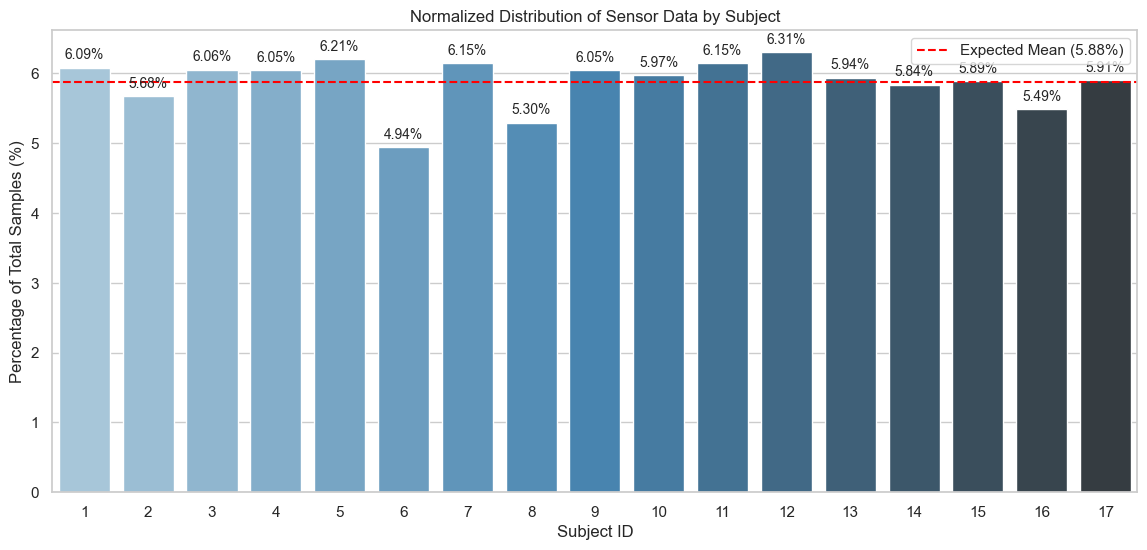

Samples per Subject (Top 5):
    Subject  total_samples  percentage
11       12          18581    6.305527
4         5          18293    6.207793
10       11          18126    6.151121
6         7          18120    6.149085
0         1          17932    6.085286


In [18]:
subject_samples = df.groupby('Subject').size().reset_index(name='total_samples')
total_dataset_samples = subject_samples['total_samples'].sum()
subject_samples['percentage'] = (subject_samples['total_samples'] / total_dataset_samples) * 100

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=subject_samples, x='Subject', y='percentage', palette='Blues_d')
expected_mean = 100 / len(subject_samples)
plt.axhline(expected_mean, color='red', linestyle='--', label=f'Expected Mean ({expected_mean:.2f}%)')

plt.title("Normalized Distribution of Sensor Data by Subject")
plt.ylabel("Percentage of Total Samples (%)")
plt.xlabel("Subject ID")
plt.legend()

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)

plt.show()

print("Samples per Subject (Top 5):")
print(subject_samples.sort_values(by='total_samples', ascending=False).head())